In [ ]:

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import SGD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from sklearn.utils import shuffle
from keras import regularizers


ecoli = pd.read_csv('/Users/blue/Desktop/Ecoli/ecoli.csv', header=None )
ecoli
x= ecoli.iloc[:,1:8].as_matrix()
y= ecoli.iloc[:, 8].as_matrix()
y = pd.get_dummies(y)

print ("x shape ", x.shape)
print ("y shape ", y.shape)



X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=5)
    
    
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_val",X_val.shape)
print("y_val",y_val.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)


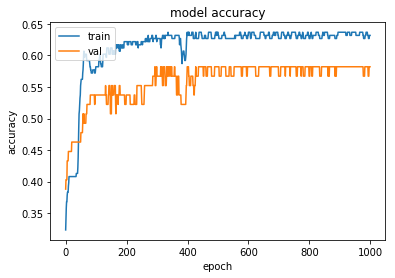

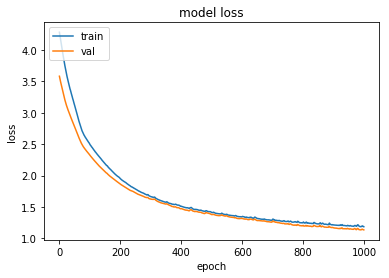

In [ ]:
""" kernel_regularizer=regularizers.l2(0.01),
    activity_regularizer=regularizers.l1(0.01)"""



model = Sequential()
model.add(Dense(4, activation='tanh', input_dim=7, kernel_regularizer=regularizers.l2(0.1),activity_regularizer=regularizers.l1(0.01)))

model.add(Dense(4, activation='tanh'))

model.add(Dense(8, activation='softmax'))

#compile, configures the model for training.
adam= keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='categorical_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=1000,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# evaluate the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()